# Phase 0 : Use Case


# Cas d’usage : Estimation automatique du prix de vente pour une plateforme immobilière en ligne

## Problème métier

L’objectif principal de notre plateforme est de permettre à un **propriétaire particulier** souhaitant vendre son bien de connaître immédiatement une **estimation objective de son prix**. Cette estimation permet :

* D’instaurer **confiance** chez le vendeur.
* De **réduire les délais de vente** en affichant un prix réaliste dès le départ.
* D’**automatiser** le processus pour limiter la mobilisation de ressources humaines coûteuses.

Dans ce cadre, nous intégrons un **modèle de machine learning** directement dans notre interface, permettant à l’utilisateur d’obtenir une **estimation instantanée** dès qu’il renseigne les caractéristiques de son bien.

---

## Rôle des données

Le jeu de données Kaggle *House Prices: Advanced Regression Techniques* constitue une base réaliste pour construire ce système :

* Il contient **79 variables descriptives** (superficie, nombre de pièces, quartier, qualité des matériaux, etc.) et un prix de vente final.
* Il reflète fidèlement les données que notre plateforme peut collecter via un formulaire rempli par l’utilisateur.

Ces données seront utilisées pour entraîner notre modèle à **prédire un prix à partir de caractéristiques connues**. Pour rester fiable, le modèle sera mis à jour régulièrement avec **de nouvelles ventes enregistrées** sur la plateforme.

---

## Acteurs concernés

1. **Vendeurs particuliers**

   * Utilisent l’outil pour obtenir une estimation fiable et gratuite.
   * Décident ensuite de mettre leur bien en ligne avec plus de sérénité.

2. **Plateforme**

   * Propose une **expérience utilisateur innovante**.
   * Génère des leads qualifiés via l’usage de l’outil d’estimation.
   * Réduit les allers-retours de négociation.

3. **Équipe Data Science**

   * Conçoit, teste, valide et surveille le modèle.
   * S’appuie sur le cycle **CRISP-ML** pour garantir la robustesse et l’évolutivité du système.

---

## Intégration du modèle dans le processus métier

* Avant : le vendeur doit consulter un agent ou faire une estimation manuelle via comparaison ou intuition.
* Après : en quelques clics, il renseigne les informations sur son bien et obtient une **fourchette de prix automatisée** (ex. : "entre 260 000 € et 280 000 €").

Cela améliore l’expérience client, limite les frictions et **valorise la data comme avantage compétitif**.

---

## Objectifs business

| Objectif                              | Description                                                                          |
| ------------------------------------- | ------------------------------------------------------------------------------------ |
| Générer des leads                     | En fournissant une estimation gratuite, on attire des vendeurs sur notre plateforme. |
| Réduire les délais de vente           | Un bon positionnement tarifaire favorise une vente rapide.                           |
| Augmenter la satisfaction utilisateur | En proposant un outil rapide et fiable.                                              |
| Réduire les coûts internes            | Moins de besoins d’agents ou d’experts mobilisés.                                    |
| Innover et se différencier            | Proposer un service basé sur des techniques de machine learning modernes.            |

---

## Approche ML envisagée

1. **Modèles testés** : Régressions (linéaire, Lasso, Ridge), Arbres de décision, Random Forest, Gradient Boosting, XGBoost.
2. **Pipeline** : Nettoyage, encodage, normalisation, sélection de features.
3. **Évaluation** : RMSE, RMSLE (notamment car recommandé pour ce challenge).
4. **Validation croisée** : Utilisation de K-Fold pour limiter l’overfitting.
5. **Hyperparamètres** : Grid Search, Random Search ou méthode bayésienne selon le modèle.

---

## Étapes CRISP-ML suivies

| Phase                  | Action                                                                                                               |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Idéation**           | Compréhension du problème métier et de l’opportunité commerciale.                                                    |
| **Data Understanding** | Exploration des variables les plus informatives (ex. : quartier, superficie, qualité).                               |
| **Design**             | Création d’un pipeline sklearn prêt à transformer `train.csv` et `test.csv`.                                         |
| **Model Engineering**  | Test de plusieurs modèles et tuning des hyperparamètres.                                                             |
| **Evaluation**         | Sélection du meilleur modèle pour la plateforme, interprétation métier.                                              |
| **Operation**          | Soumission sur Kaggle, puis intégration potentielle dans la plateforme avec monitoring, MLOps et contrôle de dérive. |

---

## Conclusion

Notre use case illustre une **application concrète du machine learning au service du business**. Grâce à l’outil d’estimation :

* Le vendeur bénéficie d’un service rapide, fiable et rassurant.
* La plateforme optimise son acquisition client et ses performances internes.
* Le modèle peut évoluer avec les tendances du marché et rester pertinent.



# Phase 1 : Phase d'idéation

## 1.1 Analyse du besoin métier et préparation des données

La mise en place d'un modèle d'estimation immobilière pour une plateforme en ligne implique d’abord une étape préliminaire cruciale consistant à préciser les attentes commerciales, à identifier précisément les indicateurs de performance du modèle, et à vérifier rigoureusement la qualité et la pertinence des données disponibles.

Dans ce contexte précis, cette étape garantit que notre solution automatisée répondra aux exigences des utilisateurs en fournissant une évaluation immobilière immédiate et objective. Elle permet également de confirmer que les informations récoltées via notre formulaire en ligne sont suffisamment qualitatives pour construire un modèle prédictif robuste et pertinent pour nos utilisateurs particuliers.


In [70]:
!pip install statsmodels
!pip install shap
!pip install -r requirements.txt

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

import math

In [72]:
plt.style.use('seaborn-v0_8') # pretty matplotlib plots

In [73]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

### 1.1.1 Aperçu des données

In [74]:
train_raw.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### 1.1.1.4 Identification de la cible du modèle

Lorsqu’on débute une analyse prédictive, il est essentiel de comprendre précisément la variable à prédire. Dans notre cas, il s'agit du montant auquel un bien immobilier sera vendu, désigné par la variable **SalePrice**.

Pour répondre spécifiquement au besoin, notre modèle exploitera diverses caractéristiques immobilières telles que la superficie, la qualité des matériaux ou encore l’emplacement, afin de prévoir précisément cette valeur finale.

In [75]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ce résumé chiffré ne permet pas une interprétabilité visuelle directe, mais indique néanmoins que la majorité des biens sont vendus dans une fourchette de prix assez resserrée : environ 130 000 pour le premier quartile, une médiane à 163 000, une moyenne à 180 000 et un troisième quartile autour de 214 000. Cette différence entre médiane et moyenne révèle la présence de quelques biens particulièrement coûteux, qui influencent la moyenne vers des valeurs supérieures.

Ce type de situation est fréquent dans l'immobilier, où un grand nombre de biens se concentrent dans une tranche de prix moyenne, tandis que quelques propriétés d’exception font nettement grimper la moyenne.

#### 1.1.1.5 Visualisation de la distribution de la variable cible

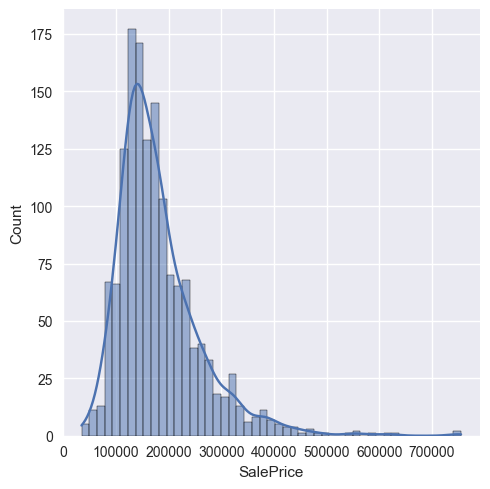

In [76]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

La distribution observée présente clairement une asymétrie marquée. Afin de confirmer statistiquement qu'elle diffère d'une distribution normale, un test d’hypothèse rapide doit être réalisé.

Dans notre scénario, l'hypothèse initiale suppose que la variable **Prix de vente** suit une distribution normale dans la population d’origine. Pour vérifier cette hypothèse, nous allons recourir au *test statistique de Shapiro-Wilk* qui, en cas de rejet, validera que les données ne sont pas distribuées normalement.

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


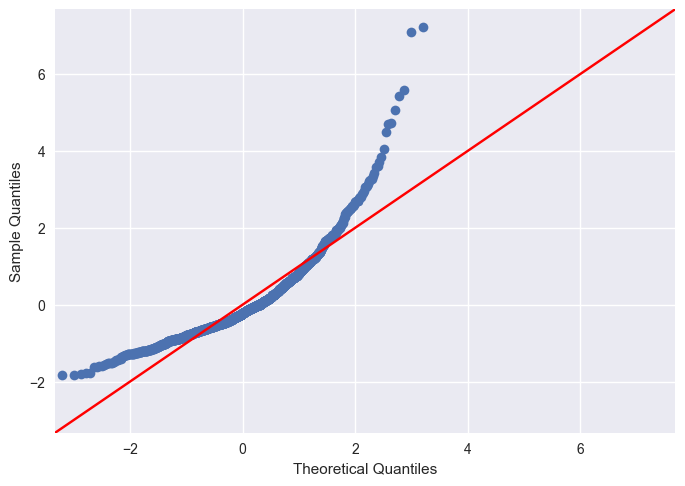

In [77]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le résultat du *test de Shapiro-Wilk* et l’analyse du **Q-Q plot** indiquent clairement que les données ne suivent pas une distribution normale. Ce constat appuie la nécessité de transformer la variable cible via une échelle logarithmique. Cette opération permet de régulariser la dispersion des valeurs et réduit l’impact disproportionné des propriétés très coûteuses sur le modèle.

#### 1.1.1.6 Transformation logarithmique de la variable cible

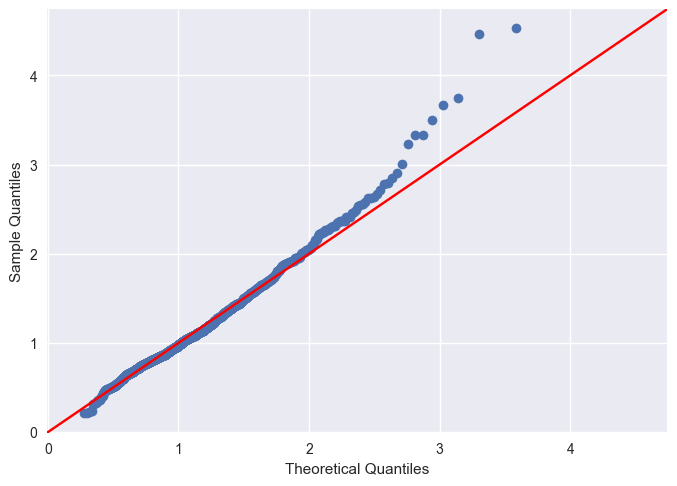

In [78]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

#### 1.1.1.7 Réduction de l’influence des valeurs extrêmes par log-transformation

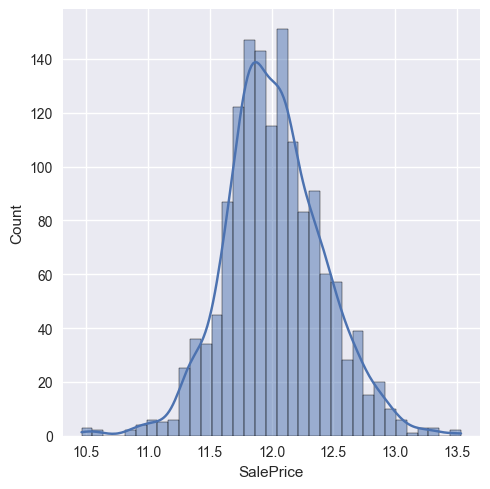

In [79]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

L'histogramme de la variable **SalePrice** après l'utilisation du logarithme `log1p`est proche d'une courbe normale. La forme est désormais symétrique et centré autour d'un pic (vers 12). Et le logarithme a permis une réduction de l'influence des valeurs extrêmes.

### 1.1.2 Variables indépendantes

Dans le jeu de données, trois types de variables sont présents : qualitatives, quantitatives et temporelles.

In [80]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

### 1.1.3 Fusion des jeux d’entraînement et de test pour un nettoyage unifié

In [81]:
data_raw = pd.concat([train_raw, validation_raw])

### 1.2 Imputation des valeurs manquantes

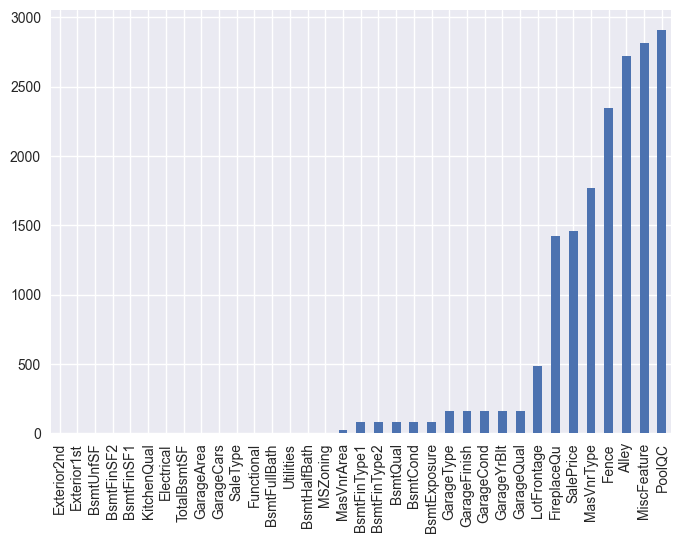

In [82]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()

        plt.show()

plot_missing(data_raw)

Nous observons que le fichier de test (test.csv) contient plus de données manquantes que celui d’entraînement (train.csv), ce qui reflète typiquement la réalité opérationnelle. Par exemple, la caractéristique **TotalBsmtSF** (surface totale du sous-sol) est toujours complète pour les biens déjà vendus (train.csv), mais comporte des lacunes pour ceux encore à évaluer (test.csv).

Ce phénomène illustre une problématique courante : les biens déjà vendus disposent souvent de dossiers détaillés, tandis que les nouvelles entrées ou les biens en cours d'estimation peuvent présenter des informations partielles.

Pour gérer efficacement cette situation, nous avons décidé d'associer temporairement les jeux d'entraînement et de test pendant l'exploration initiale. Ce procédé assure un traitement homogène des données absentes et garantit un prétraitement stable pour toutes les futures évaluations effectuées par l’agence.

### 1.2.1 Variables quantitatives

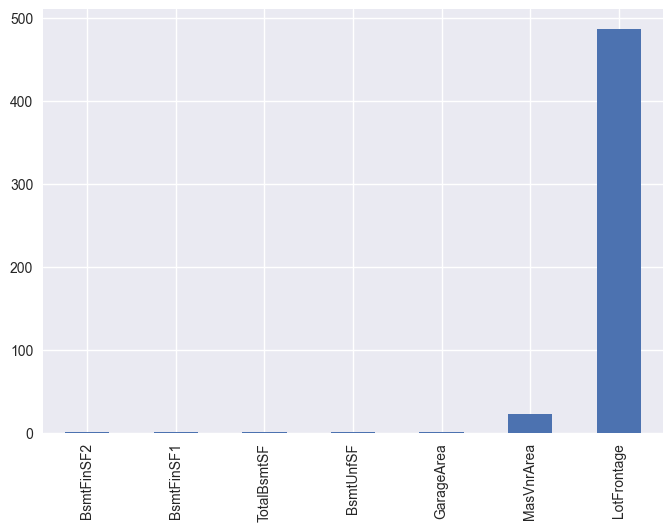

In [83]:
# Affichage des variables manquantes
plot_missing(data_raw[quantitative])

La stratégie qui fait le plus de sens est de remplir les valeurs manquantes par zéro (0). En effet, les valeurs manquantes indiquent qu'elles ne sont pas présentes dans le bien immobilier, et donc qu'elles sont égales à zéro. Par exemple, si un bien n'a pas de garage, la surface du garage est nulle. De même, si un bien n'a pas de sous-sol, la surface du sous-sol est également nulle.

In [84]:
# Pour les variables quantitatives, nous allons remplir les colonnes avec 0
def fill_missing_with_constant(data, columns, constant):

    data_clean = data.copy()

    for c in columns :

        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)

    return data_clean

### 1.2.2 Variables qualitatives

La stratégie qui fait le plus de sens pour les variables qualitatives est de remplir les valeurs manquantes par 'NA', comme on le ferait en Business Intelligence.

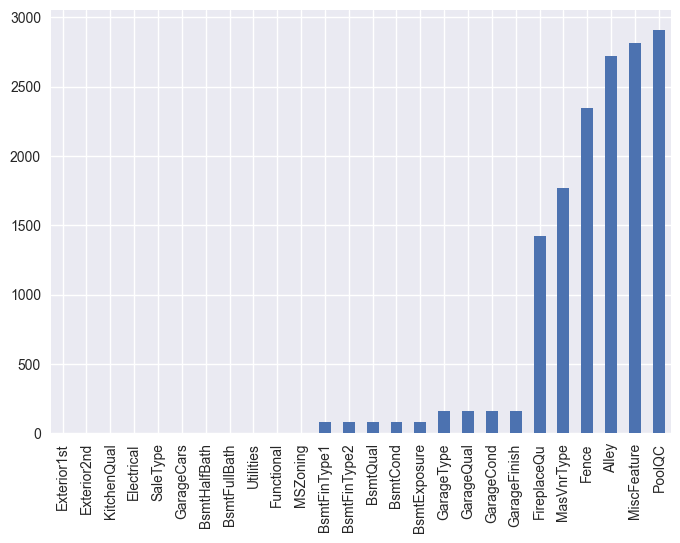

In [85]:
plot_missing(data_raw[qualitative])

_Nous n'avons pas besoin de définir une fonction particulière pour cela car nous utilisons la fonction fill_missing_with_constant définie précédemment._

### 1.2.3 Variables temporelles

Nous pouvons voir que la seule variable temporelle qui a des valeurs manquantes est **GarageYrBlt**, probablement parce que la maison n'a pas de garage. Ainsi, remplaçons cette date par **YearBuilt**, ce qui a du sens d'un point de vue métier.

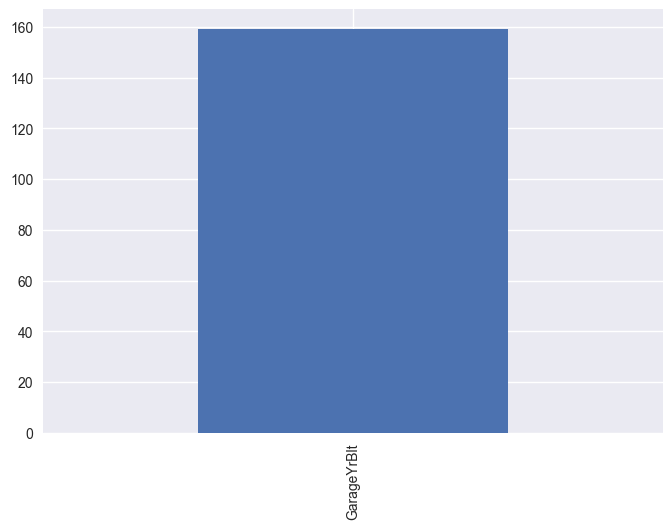

In [86]:
plot_missing(data_raw[date])

In [87]:
# Pour les variables temporelles, nous allons remplir les valeurs manquantes en utilisant les valeurs d'une autre colonne
def fill_missing_with_column(data, missing, column) :

    data_clean = data.copy()

    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])

    return data_clean

## 1.3 Transformation de base

Étant donné que les ventes vont de 2006 à 2010, il serait logique de calculer le nombre d'années depuis la construction de la maison, sa rénovation, etc.

In [88]:
def compute_differences_to_year_sold(data) :

    data_clean = data.copy()

    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']

    return data_clean

## 1.4 Exécution du processus de nettoyage

In [89]:
def clean(data) :

    data_clean = data.copy()

    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)

    return data_clean

data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Analyse exploratoire des données (EDA)

Nous allons maintenant effectuer l'EDA et réfléchir à la manière dont nous allons résoudre ce cas. Nous avons deux types de variables, les variables catégorielles et les variables numériques. De plus, nous devons diviser notre ensemble de données nettoyé en un ensemble d'entraînement et un ensemble de validation comme auparavant.

In [90]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### 1.5.1 Analyse des variables numériques

Il est assez standard de regarder la corrélation entre chaque variable numérique et notre variable cible, c'est-à-dire le logarithme de SalePrice. Attention à ne pas effectuer une corrélation avec SalePrice lui-même, car le lien n'est probablement pas linéaire comme nous l'avons vu précédemment.

In [91]:
def correlation(y, X, features, method = 'pearson'):

    cor = pd.DataFrame()
    cor['feature'] = features

    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)

    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')

    return cor

Voyons ensuite les corrélations entre les variables numériques et le logarithme de SalePrice sur l'ensemble de données train_clean.

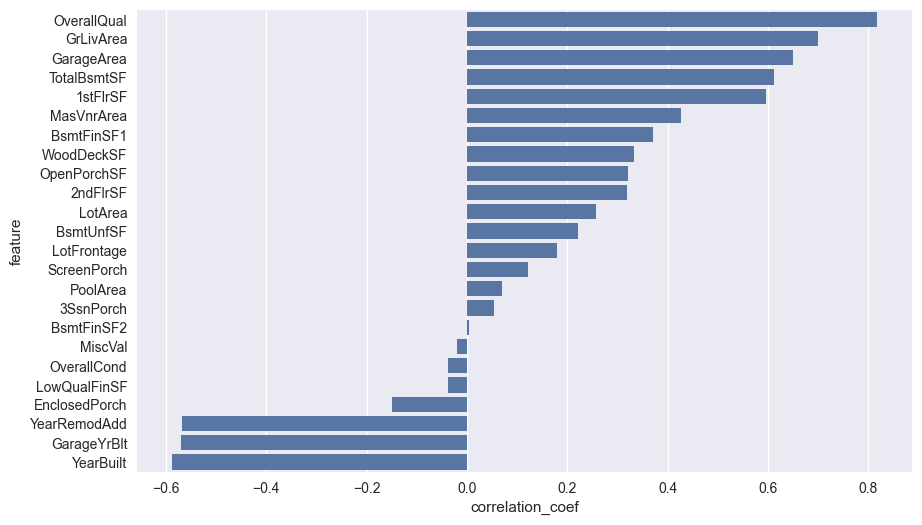

In [92]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

La valeur de corrélation elle-même peut être trompeuse, il faut tracer les nuages de points. Traçons tous les nuages de points pour ces caractéristiques numériques.

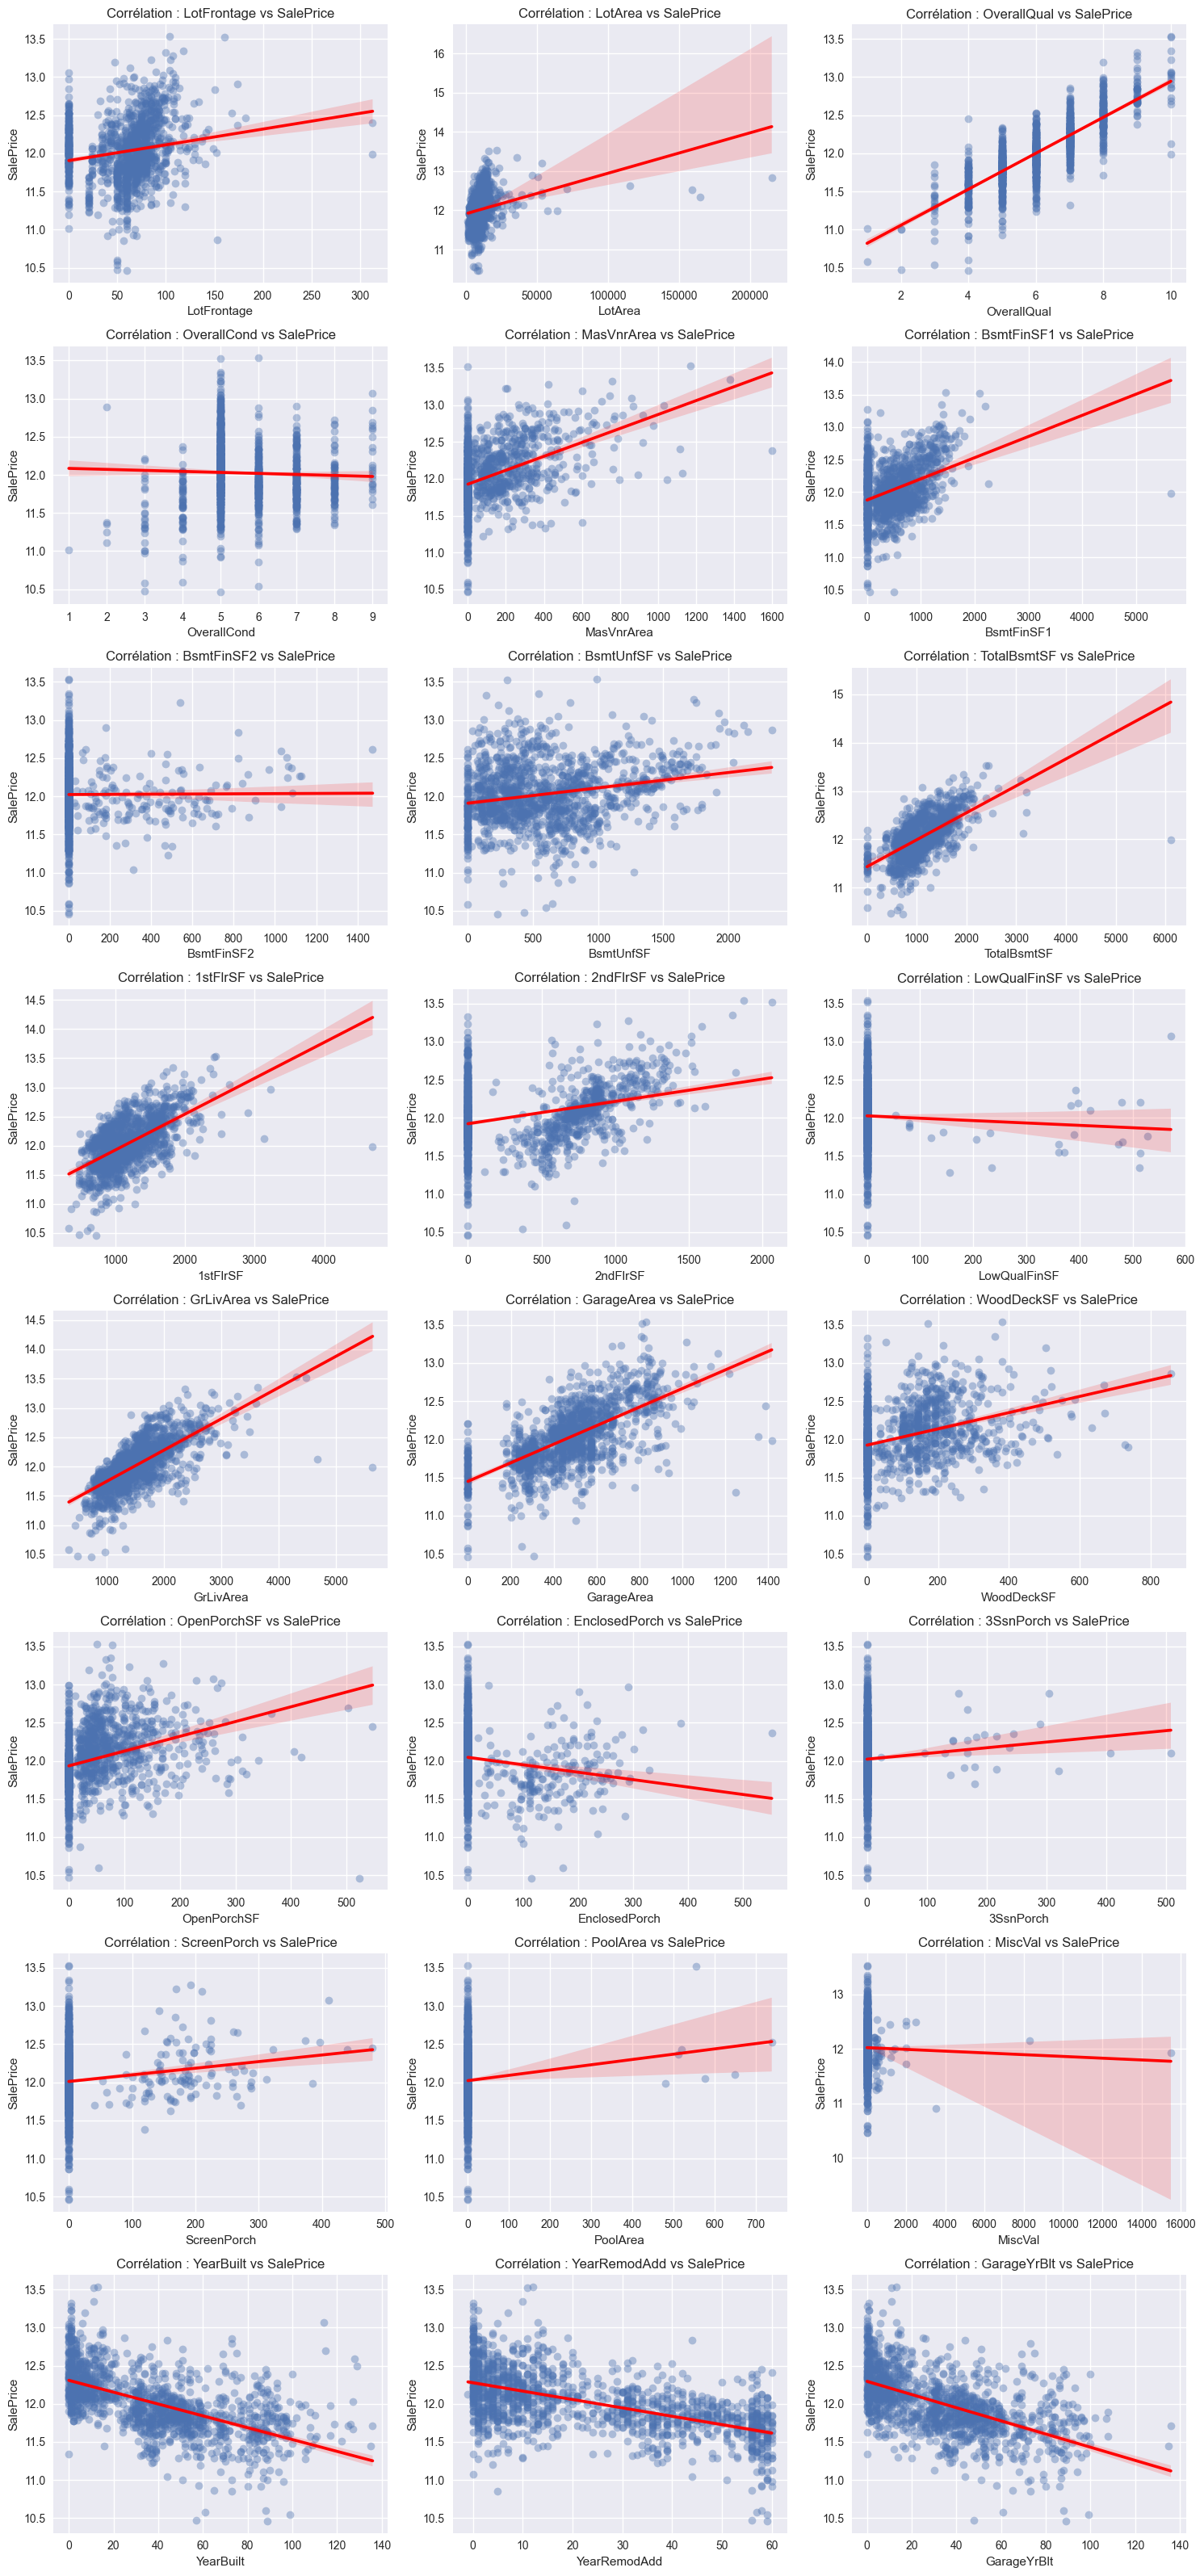

In [93]:
def scatter_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        x = X[f]
        sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
        axes[i].set_title(f'Corrélation : {f} vs {y.name}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

scatter_plots_grid(target, train_clean, numeric)

Les 24 graphiques présentés ci-dessus illustrent les relations entre diverses variables numériques et le prix de vente (SalePrice, transformé en logarithme). Ces visualisations permettent d'identifier rapidement les variables ayant un impact significatif sur le prix et celles qui peuvent être exclues de notre modélisation.

### Variables avec une forte corrélation

| Variable |
|----------|
| OverallQual |
| GrLivArea |
| TotalBsmtSF |
| 1stFlrSF |
| GarageArea |

Ces variables présentent une relation linéaire claire et ascendante avec le prix de vente. Elles indiquent une tendance nette : une augmentation de leur valeur est associée à une hausse du prix de vente. Par conséquent, elles constituent des prédicteurs robustes à intégrer dans notre modèle.

### Variables avec une corrélation modérée

| Variable |
|----------|
| LotArea |
| MasVnrArea |
| WoodDeckSF |
| OpenPorchSF |
| ScreenPorch |
| PoolArea |

Bien que la tendance soit moins marquée pour ces variables, elles peuvent néanmoins apporter une valeur explicative supplémentaire, notamment lorsqu'elles sont combinées avec d'autres. Par exemple, la présence d'une piscine ou d'une terrasse peut contribuer à une estimation plus précise dans des contextes spécifiques.

### Variables avec peu ou pas de lien apparent

| Variable |
|----------|
| LotFrontage |
| OverallCond |
| BsmtUnfSF |
| BsmtFinSF2 |
| 2ndFlrSF |
| GarageYrBlt |
| YearBuilt |
| YearRemodAdd |

Ces variables montrent une dispersion importante ou une relation presque horizontale avec le prix de vente. Leur contribution semble limitée ou confuse, et elles pourraient être exclues du modèle ou retravaillées, par exemple, par encodage ou regroupement.

### Variables sans intérêt ou contre-productives

| Variable |
|----------|
| LowQualFinSF |
| EnclosedPorch |
| 3SsnPorch |
| MiscVal |

Ces variables présentent peu de valeurs non nulles et n'apportent aucun signal clair sur le prix de vente. Elles peuvent être considérées comme non pertinentes pour la prédiction et pourraient être exclues de l'analyse.

### 1.5.2 Analyse des variables catégorielles

Pour les variables catégorielles, nous ne pouvons pas effectuer de corrélation pour des raisons évidentes. Nous devons donc effectuer une ANOVA (https://fr.wikipedia.org/wiki/Analyse_de_variance) qui est le pendant dans le cas où nous voulons comprendre le lien entre une variable catégorielle et une variable numérique.

L'ANOVA (Analyse de Variance) est une méthode statistique qui permet de comparer les moyennes de plusieurs groupes pour déterminer s'il existe des différences significatives entre eux. Dans notre cas, nous allons l'utiliser pour évaluer si les différentes catégories d'une variable qualitative ont un impact significatif sur la variable numérique cible, le prix de vente (logarithme de SalePrice).

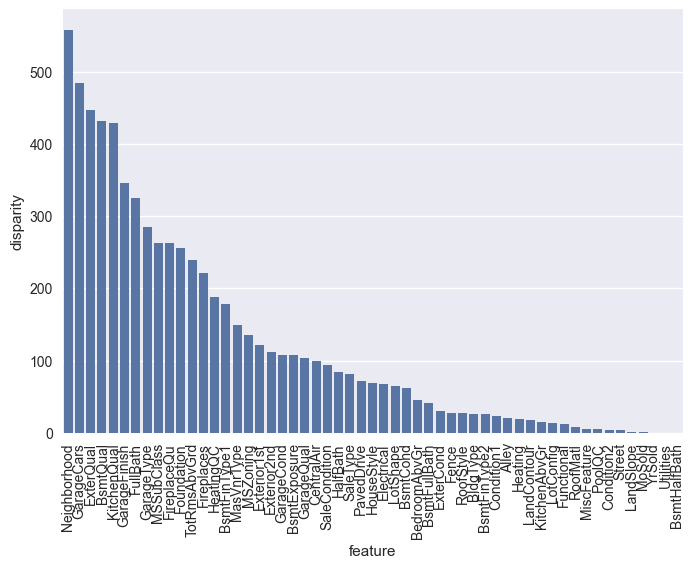

In [94]:
def anova(y, X, features):

    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []

    for f in features:

        samples = []

        for cls in X[f].unique():

            s = y[X[f] == cls].values
            samples.append(s)

        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)

    anova['pval'] = pvals
    anova = anova.sort_values('pval')

    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)

    return anova

anova = anova(target, train_clean, categorical)

Ce graphique, issu de l'analyse ANOVA, permet d'identifier les variables catégorielles qui différencient le plus les prix de vente selon leurs modalités.

Par exemple, des variables comme Neighborhood, ExterQual ou KitchenQual montrent une forte disparité entre les groupes, ce qui indique qu'elles ont un impact plus marqué que d'autres variables comme Street ou BsmtHalfBath.

Cependant, une forte disparité ne signifie pas forcément une grande influence directe sur le prix de vente, mais plutôt que la variable permet de mieux séparer les niveaux de prix entre ses catégories.

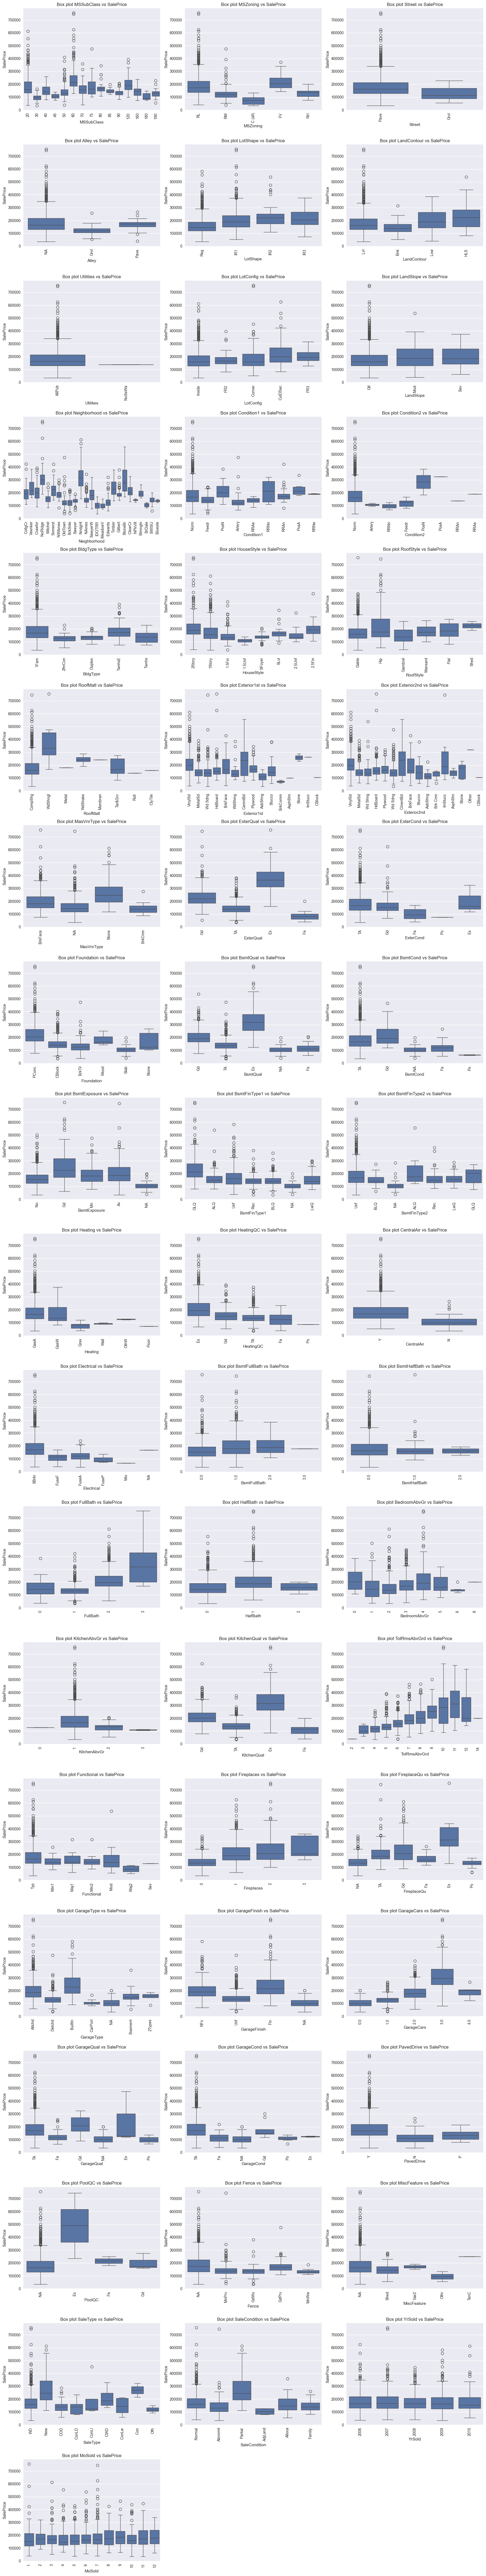

In [95]:
def box_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        sns.boxplot(x=X[f], y=y, ax=axes[i])
        axes[i].set_title(f'Box plot {f} vs {y.name}')
        axes[i].tick_params(axis='x', rotation=90)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

box_plots_grid(train_clean['SalePrice'], train_clean, categorical)

# Phase 2 : Phase de design

Créons maintenant notre modèle. Nous commencerons par un modèle de base puis augmenterons la complexité.

## 2.1  Ingénierie des données de base

Pour effectuer une analyse de régression, nous devons préparer un peu plus notre ensemble de données. En particulier, nous allons transformer les variables catégorielles en numériques.

Dans notre scénario de régression, il est intéressant de remplacer la catégorie par la moyenne de notre variable cible pour cette catégorie. Cette transformation crée alors une corrélation naturelle entre notre nouvelle variable et notre variable cible. Une autre approche (dummy) serait d'utiliser simplement pd.getDummies(), mais ce n'est pas aussi efficace et trompeur à mon avis.

In [96]:
def encode_with_mean(data, target, features):

    data_preprocess = data.copy()

    for f in features:

        # create a temporary dataframe for our workload
        frame = pd.DataFrame()
        frame[f] = data[f].copy()
        frame[target.name] = target.copy()

        # create the mapping table
        mapping = pd.DataFrame()
        mapping['val'] = data[f].unique()
        mapping.index = mapping.val

        # compute the mean of our target variable for each category
        mapping['mean'] = frame[[f, target.name]].groupby(f).mean()[target.name]

        # if a category has NA, we shall simply put the mean value
        mapping['mean'] = mapping['mean'].fillna(target.mean())

        # we replace the feature with the means in the mapping table
        data_preprocess[f] = pd.merge(data_preprocess, mapping, left_on = f, right_index = True)['mean'].copy()

    return data_preprocess

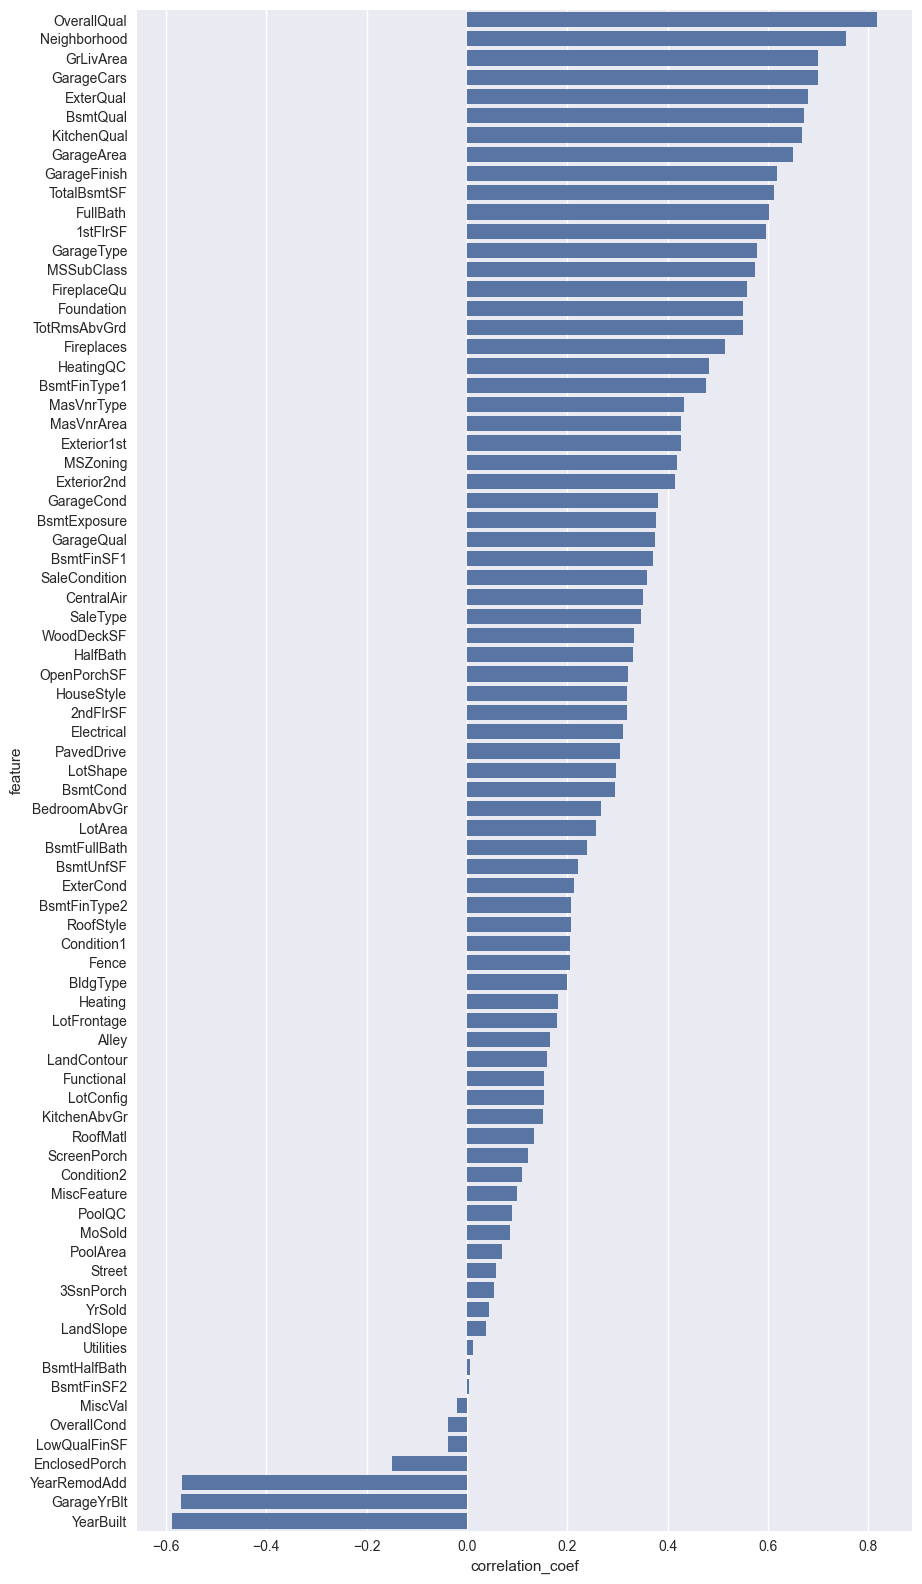

In [97]:
data_preprocess = encode_with_mean(data_clean, target, categorical)

# Split of the clean dataset into train & validation
train_preprocess = data_preprocess[data_preprocess.index.isin(train_raw.index)]
validation_preprocess = data_preprocess[data_preprocess.index.isin(validation_raw.index)]

cor = correlation(target, train_preprocess, numeric + categorical)

Nous voyons que de nombreuses caractéristiques sont corrélées avec le logarithme de SalePrice, ce qui est bon pour notre cas d'utilisation. Jetons un coup d'œil à la corrélation interne entre les variables. Nous limitons notre visualisation aux caractéristiques qui ont une corrélation modérée ou supérieure (c'est-à-dire un coefficient de corrélation supérieur à 0,5 en valeur absolue).

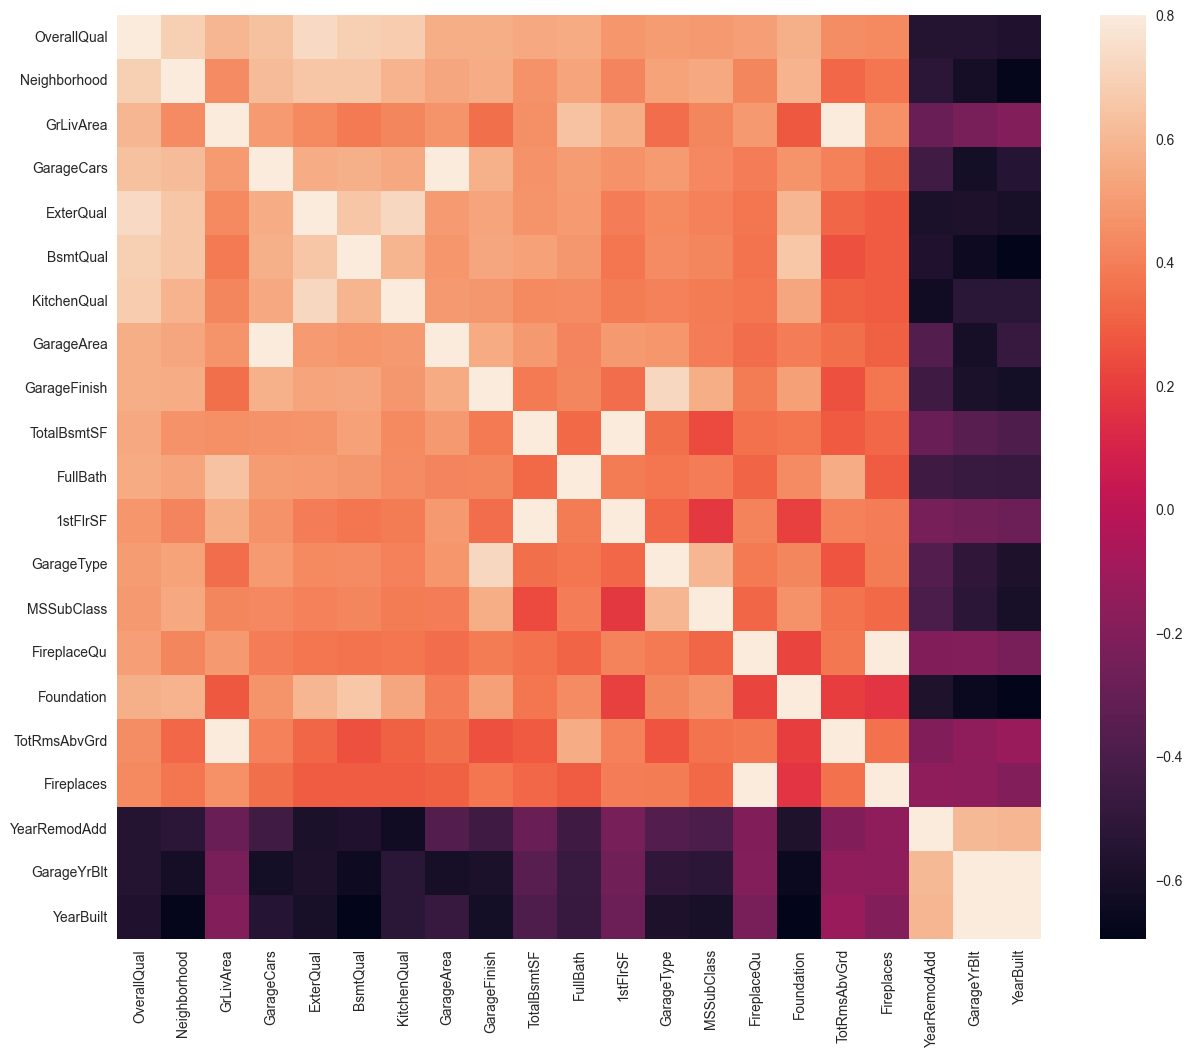

In [98]:
cols = cor[abs(cor['correlation_coef']) > 0.5]['feature'].tolist()
correlation_matrix = train_preprocess[cols].corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(correlation_matrix, vmax=.8, square=True)
plt.show()

Il y a beaucoup de corrélation interne. Nous devrons donc sélectionner soigneusement les variables afin d'éviter la multicolinéarité.

## 2.2 Modèle de base - régression linéaire

Nous commençons par le modèle le plus basique de tous, à savoir la régression linéaire. D'après notre analyse et notre compréhension du marché immobilier, il est intéressant de considérer les variables suivantes :

- OverallQual
- Neighborhood
- GrLivArea
- TotalBsmtSF
- YearBuilt

Cela a tout à fait du sens, car ce sont les variables principales que l'on recherche pour une maison, à savoir la qualité globale du bien, le quartier, la surface habitable et l'année de construction de la maison. Le sous-sol est particulièrement important à Ames car c'est une région à haut risque de tornades.

In [99]:
base = ['OverallQual', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

X = train_preprocess[base]
X_val = validation_preprocess[base]

y = target.copy()

Pour ajuster la régression linéaire, nous utilisons la bibliothèque StatsModels qui propose des fonctions très pratiques pour comprendre le modèle.

In [100]:
model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:              jeu., 19 juin 2025   Prob (F-statistic):               0.00
Time:                        19:12:13   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

### 2.2.1 Hypothèses de régression linéaire

Si nous souhaitons utiliser une régression linéaire, nous devons vérifier certaines hypothèses, à savoir :

- Linéarité du lien entre les variables indépendantes et la variable dépendante
- Les résidus sont normalement distribués autour de 0
- Homoscédasticité
- Les résidus sont exempts de structure
- Les résidus sont exempts de valeurs aberrantes

Voici un code, via [ce site](https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/), qui réalise cela très bien.

In [101]:
from statsmodels.graphics.gofplots import ProbPlot
plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)

def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)

    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]

    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x = model_fitted_y, y = dataframe.columns[-1], data = dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');

    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));

    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));

    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x = model_fitted_y, y = model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');

    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]));

    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x = model_leverage, y = model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage)+0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));

    p = len(model_fit.params) # number of model parameters
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50),
          'Cook\'s distance') # 0.5 line
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50)) # 1 line
    plot_lm_4.legend(loc='upper right');

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ludom\AppData\Local\Temp\ipykernel_32356\2729062031.py:92: SyntaxWarning: invalid escape sequence '\s'
  plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');


c:\Users\ludom\Desktop\HEG\6eSemestre\ProjetDataScience\ProjetV2\OverfittingRepo\env\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


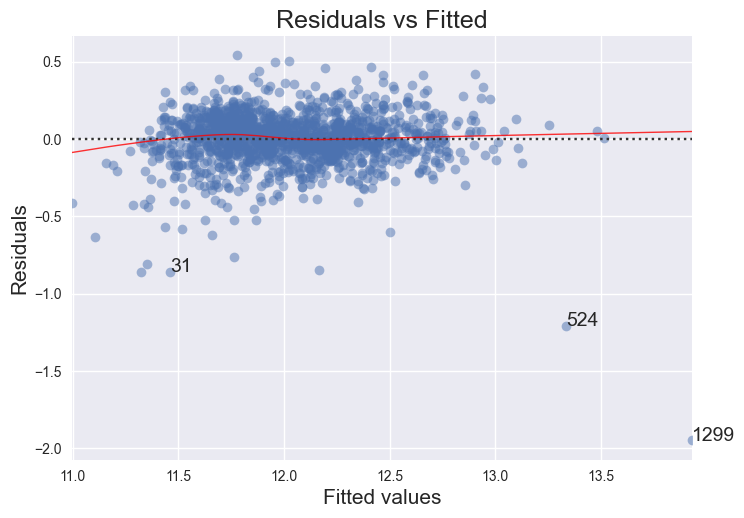

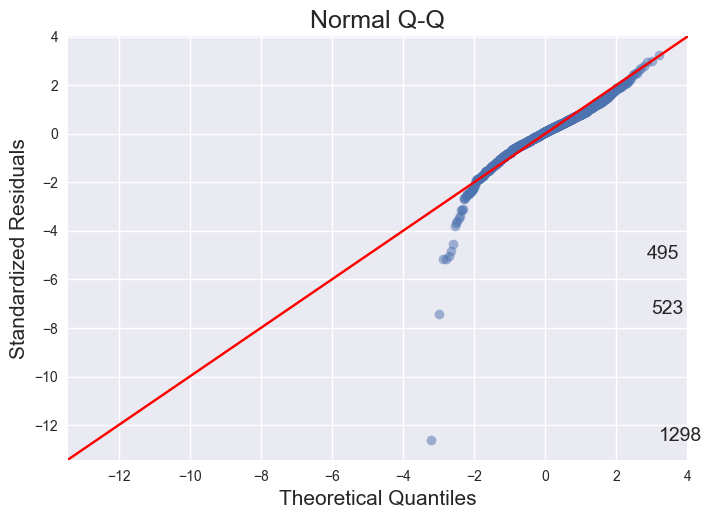

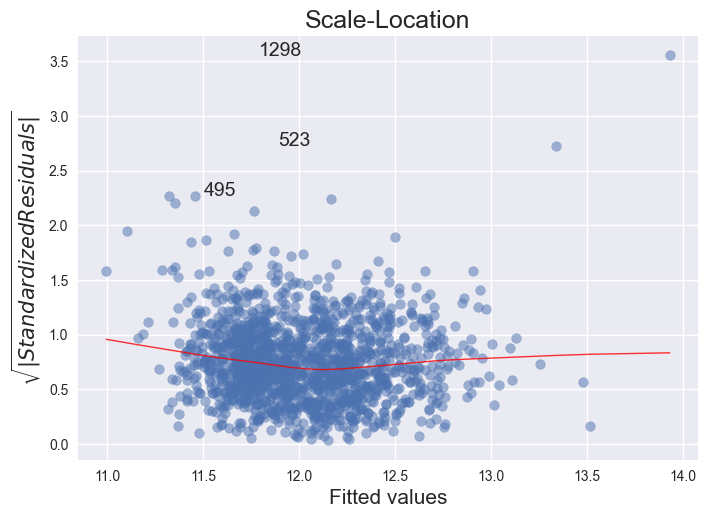

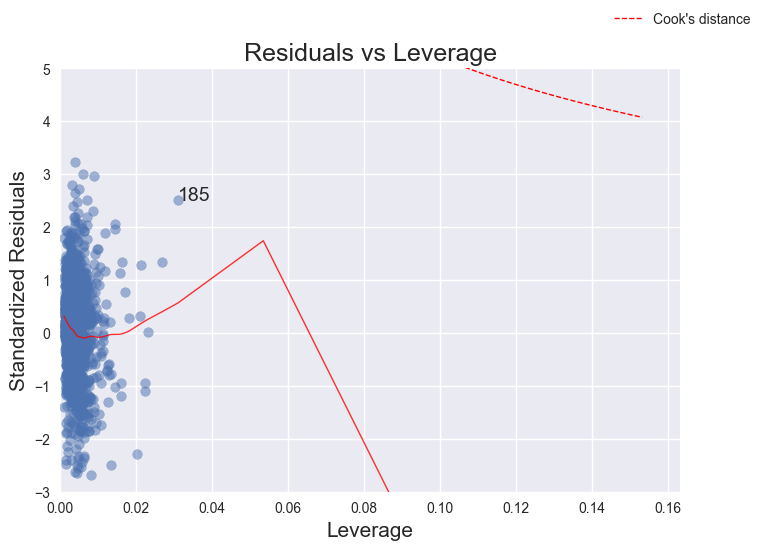

In [ ]:
diagnostic_plots(sm.add_constant(X), y)

### 2.2.2 Analyse résiduelle

Les résidus semblent exempts de structure et semblent normalement distribués autour de 0. Cependant, nous observons quelques valeurs aberrantes dans les résidus. Jetons un coup d'œil à ces données.

In [103]:
print(X[base].iloc[[523, 1298]])

      OverallQual  Neighborhood  GrLivArea  TotalBsmtSF  YearBuilt
Id                                                                
524            10     11.712321       4676       3138.0          0
1299           10     11.712321       5642       6110.0          0


In the documentation (http://jse.amstat.org/v19n3/decock/DataDocumentation.txt), we can read

SPECIAL NOTES: There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students.

Thus, let's have a look at the outliers, especially on the column GrLivArea.

In [104]:
def remove_outliers(data, target, feature):

    data_preprocess = data.copy()
    data_preprocess[target.name] = target.copy()

    #Compute interquartile range
    q1 = data_preprocess[feature].quantile(0.25)
    q3 = data_preprocess[feature].quantile(0.75)

    iqr = q3-q1

    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    data_preprocess = data_preprocess.loc[(data_preprocess[feature] > fence_low) & (data_preprocess[feature] < fence_high)]

    return data_preprocess[data.columns], data_preprocess[target.name]

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1522.
Date:              jeu., 19 juin 2025   Prob (F-statistic):               0.00
Time:                        19:12:18   Log-Likelihood:                 659.93
No. Observations:                1429   AIC:                            -1308.
Df Residuals:                    1423   BIC:                            -1276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7556      0.257     30.195   

c:\Users\ludom\Desktop\HEG\6eSemestre\ProjetDataScience\ProjetV2\OverfittingRepo\env\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


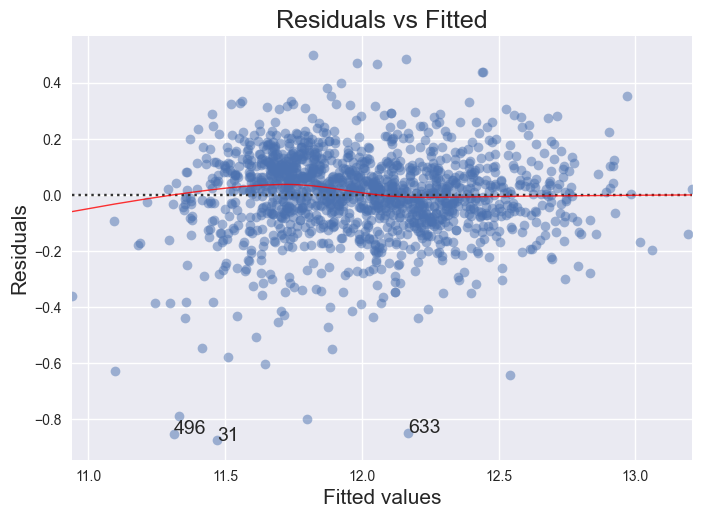

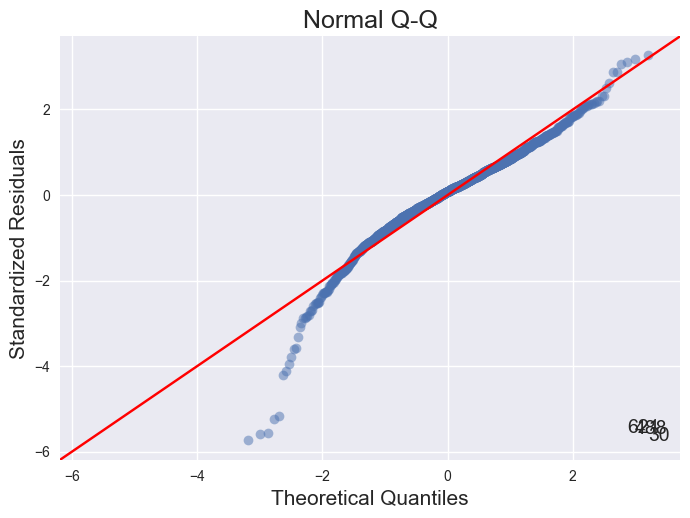

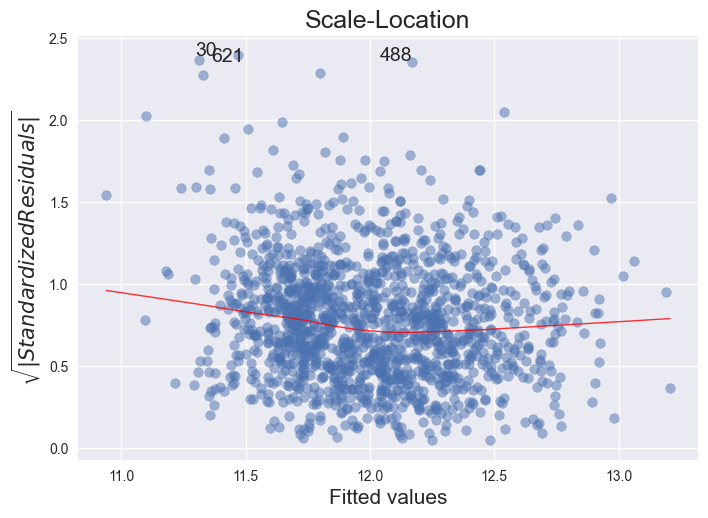

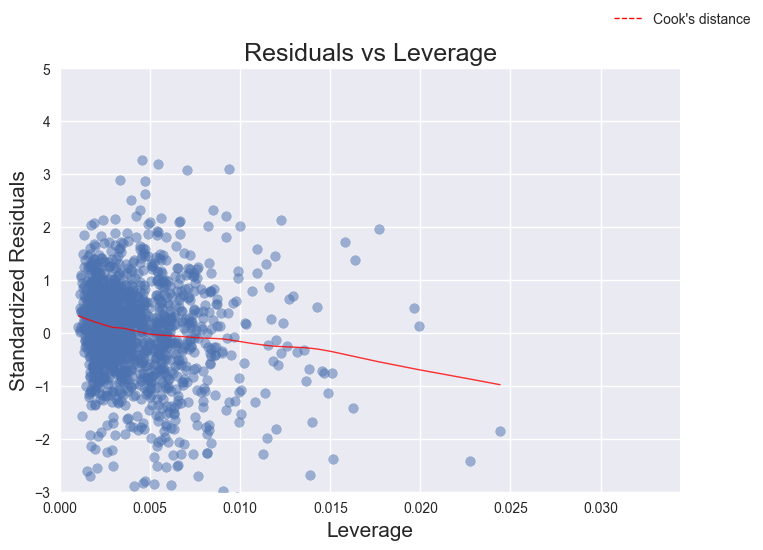

In [105]:
# exécution de la fonction pour supprimer les valeurs aberrantes

X, y = remove_outliers(X, y, feature = 'GrLivArea')

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

diagnostic_plots(sm.add_constant(X), y)


### Résumé de nos actions sur le modèle de base

**Nettoyage & amélioration du modèle de régression :**
Nous avons supprimé les valeurs aberrantes en nous concentrant sur la variable `GrLivArea`, grâce à la fonction `remove_outliers()`. Cette étape a permis de réduire l'impact des observations extrêmes sur l'entraînement du modèle.

Nous avons ensuite réentraîné notre modèle OLS (régression linéaire) avec les données nettoyées. Les graphiques de diagnostic obtenus montrent clairement une amélioration :

* Moins de dispersion extrême dans les résidus.
* Une distribution des résidus plus proche d’une loi normale (Q-Q plot).
* Une réduction notable des points influents sur le graphe "residuals vs leverage".

**Résultats du modèle après nettoyage :**

* Le coefficient de détermination R² est passé de **0.825 à 0.842**, ce qui indique une meilleure capacité explicative.
* Tous les coefficients du modèle sont restés **hautement significatifs** (p < 0.001).
* Le modèle gagne en robustesse tout en réduisant la variance des erreurs.

Nous pouvons ainsi constater que la gestion proactive des outliers contribue directement à renforcer la stabilité et la performance prédictive de notre modèle de base.


Ok, c'est beaucoup mieux. Évaluons maintenant notre modèle de base et voyons comment il se comporte sur Kaggle. Nous utiliserons la méthode predict pour cela.

In [106]:
y_pred = res.predict(sm.add_constant(X))
print(y_pred.head())

Id
1    12.214534
2    12.081588
3    12.244451
4    12.046219
5    12.620316
dtype: float64


Nous allons visualiser le nuage de points où nous comparons la valeur réelle et les valeurs prédites.

In [107]:
def plot_prediction(actual, predicted) :

    data = pd.concat([actual, predicted], keys = ['actual', 'predicted'], axis = 1)

    plt.title('Actual vs Predicted')
    sns.regplot(x = 'actual', y = 'predicted', data = data)
    plt.show()

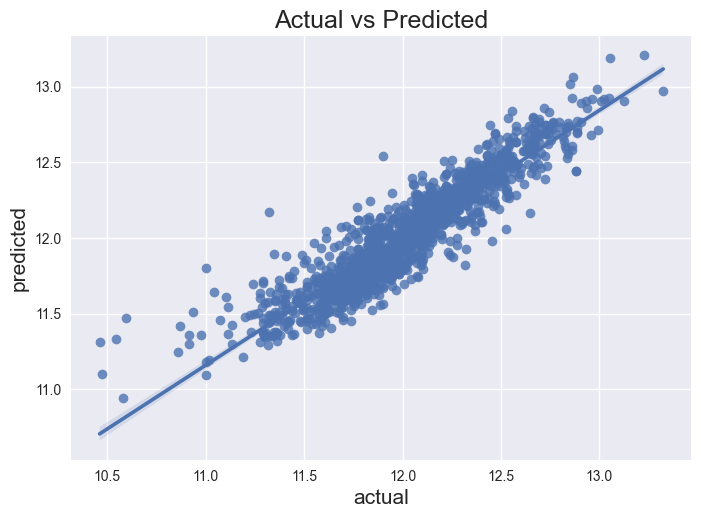

In [108]:
plot_prediction(y, y_pred)

Cela semble fonctionner correctement. Attention au surapprentissage ici, car nous avons prédit et ajusté sur le même ensemble de données. Pour des modèles plus complexes, cela pourrait poser un problème sérieux.

In [109]:
from sklearn.metrics import mean_squared_error

def rmse(actual, predicted) :
    return np.sqrt(mean_squared_error(actual, predicted))

In [110]:
print('Root Mean Square Error (RMSE) :', rmse(y, y_pred))

Root Mean Square Error (RMSE) : 0.1524750806291098


## 2.3 Soumission du modèle Baseline sur Kaggle

Nous utilisons la méthode predict sur le jeu de données de validation.

In [113]:
y_val = res.predict(sm.add_constant(X_val))

print(y_val.head())

Id
1461    11.663271
1462    11.946171
1463    12.025787
1464    12.101195
1465    12.341289
dtype: float64


Nous écrivons maintenant nos prédictions dans le fichier _baseline.csv_ et n'oublions pas d'utiliser la fonction inverse de **np.log1p**, à savoir **np.expm1**.

In [114]:
submission = pd.DataFrame()
submission['Id'] = y_val.index
submission['SalePrice'] = np.expm1(y_val.values)

submission.to_csv('Data/baseline.csv', index = False)

### **Résumé de la Phase 2.1 – Data Engineering & Modèle de base**

Au cours de cette phase, nous avons construit un **modèle baseline** de régression linéaire sur un sous-ensemble de variables sélectionnées pour leur pertinence métier et leur corrélation avec le prix (`SalePrice`) : `OverallQual`, `Neighborhood`, `GrLivArea`, `TotalBsmtSF` et `YearBuilt`.

Pour améliorer la stabilité du modèle, nous avons :

* Nettoyé les données en supprimant des **valeurs aberrantes** sur la variable `GrLivArea`.
* Transformé les variables catégorielles (`Neighborhood`) via un **encodage par moyenne cible**, plus adapté au contexte d'une régression linéaire que l'encodage one-hot classique.
* Vérifié les hypothèses du modèle à travers une **analyse des résidus** (distribution normale, homoscédasticité, leverage).

Le modèle obtenu présente des performances solides :

* **R² = 0.842**, ce qui signifie qu’il explique 84,2 % de la variance des prix.
* **RMSE (log) ≈ 0.152**, indiquant une erreur relative moyenne raisonnable.
* Les diagnostics montrent une **réduction des biais et une meilleure distribution des résidus**.

Enfin, ce modèle a été utilisé pour générer une **soumission Kaggle**, servant ainsi de **référence** pour la suite du projet.

---

### **Poursuite de la Phase 2.1 – Mise en place d’un pipeline `sklearn`**

Avant de passer à la phase de modélisation avancée, nous allons poursuivre la phase 2.1 en construisant un **pipeline `scikit-learn` complet**. Celui-ci permettra :

* D’automatiser le traitement des données : encodage, imputation, standardisation.
* De garantir la reproductibilité et la cohérence entre les données d'entraînement et de test.
* De simplifier l’évaluation de modèles plus complexes par la suite.

---

### **Phase 2.2 – Model Engineering : tests de modèles avancés**

Une fois le pipeline mis en place, nous entamerons la phase 2.2, dédiée à l’**exploration de modèles plus puissants** :

* Régressions régularisées : **Ridge**, **Lasso**, **ElasticNet**.
* Modèles d’ensemble : **Random Forest**, **Gradient Boosting** (XGBoost, LightGBM).
* Optimisation automatique des hyperparamètres à l’aide de la librairie Optuna, pour gagner en efficacité et en performance.
* Évaluation rigoureuse par **validation croisée**.

L’objectif sera d’obtenir un modèle **plus performant que notre baseline**, mieux généralisable et plus robuste.


# 2.4 Mise en place d’un pipeline de prétraitement commun

Avant de comparer différents modèles de régression, nous construisons un pipeline scikit-learn qui regroupe toutes les étapes de préparation des données. Cela garantit que :

Chaque modèle reçoit les mêmes données correctement transformées.
Le code reste modulaire, clair et facilement extensible.
Les performances des modèles sont comparables dans des conditions identiques.

Notre pipeline inclut :

L’imputation des données manquantes (médiane pour les numériques, constante 'NA' pour les catégorielles),

L’encodage des variables catégorielles nominales via OneHotEncoder,

La standardisation des variables numériques via StandardScaler.

Nous utilisons ensuite ce pipeline pour entraîner nos modèles (Ridge, Lasso, Random Forest et XGBoost) avec ou sans recherche d’hyperparamètres.



# 2.4.1 Nettoyage cohérent des données avant le pipeline
Avant de construire notre pipeline scikit-learn, nous avons appliqué une série d’étapes de nettoyage essentielles afin de garantir :

La cohérence des données entre le jeu d’entraînement et celui de validation/test,

L’exploitation correcte des variables temporelles,

Une gestion robuste des valeurs manquantes.

Ces étapes comprennent notamment :

Le remplissage des valeurs manquantes par 0 (quantitatif) ou "NA" (catégoriel),

Le remplacement de GarageYrBlt manquant par la valeur de YearBuilt,

La transformation des dates (YearBuilt, YearRemodAdd, GarageYrBlt) en durée depuis YrSold,

La suppression d’outliers extrêmes sur GrLivArea.

Nous avons regroupé ces actions dans une fonction dédiée, appliquée systématiquement avant tout entraînement de modèle. Cela garantit une reproductibilité du traitement, essentielle pour comparer nos modèles de manière équitable.

In [135]:
def clean_raw_data(data, quantitative, qualitative, date_cols):
    """
    Nettoie un DataFrame brut en appliquant les étapes suivantes :
    - Remplissage des NaN : 0 pour les colonnes quantitatives, "NA" pour les qualitatives
    - Remplacement de GarageYrBlt manquant par YearBuilt
    - Transformation des dates : remplace par la différence avec YrSold

    Parameters:
        data (pd.DataFrame): Données brutes à nettoyer
        quantitative (list): Liste des colonnes numériques
        qualitative (list): Liste des colonnes catégorielles
        date_cols (list): Liste des colonnes à convertir en années écoulées

    Returns:
        pd.DataFrame: Données nettoyées
    """
    data_clean = data.copy()

    # 1. Remplir les NaN des colonnes numériques avec 0
    for col in quantitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna(0)

    # 2. Remplir les NaN des colonnes qualitatives avec "NA"
    for col in qualitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna("NA")

    # 3. Remplacer GarageYrBlt manquant par YearBuilt
    if "GarageYrBlt" in data_clean.columns and "YearBuilt" in data_clean.columns:
        data_clean["GarageYrBlt"] = np.where(
            data_clean["GarageYrBlt"].isnull(),
            data_clean["YearBuilt"],
            data_clean["GarageYrBlt"]
        )

    # 4. Transformer les dates en durée par rapport à YrSold
    if "YrSold" in data_clean.columns:
        for col in date_cols:
            if col in data_clean.columns:
                data_clean[col] = data_clean["YrSold"] - data_clean[col]

    return data_clean


In [137]:
# Chargement brut
train_raw = pd.read_csv("Data/train.csv", index_col="Id")
test_raw = pd.read_csv("Data/test.csv", index_col="Id")

# Cibles
target = np.log1p(train_raw["SalePrice"])  # log-transformation
train_raw = train_raw.drop(columns=["SalePrice"])

# Fusion pour nettoyage homogène
full_raw = pd.concat([train_raw, test_raw])

# Colonnes définies plus tôt
quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                'PoolArea', 'MiscVal']

qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

date_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Nettoyage
full_clean = clean_raw_data(full_raw, quantitative, qualitative, date_cols)

# Re-séparation
train_clean = full_clean.loc[train_raw.index]
test_clean = full_clean.loc[test_raw.index]


In [138]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identification des types après nettoyage
numeric_features = train_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train_clean.select_dtypes(include=["object"]).columns.tolist()

# Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


# 2.5 Model Engineering

# 2.5.1 Modèle 1 : Régression Ridge avec GridSearchCV
Nous commençons notre phase de modélisation par la régression Ridge, une extension de la régression linéaire classique qui ajoute une pénalisation L2 sur les coefficients du modèle. Cette régularisation permet de :

Réduire les risques de surapprentissage,

Gérer la multicolinéarité entre les variables explicatives,

Stabiliser les prédictions quand de nombreuses variables sont corrélées.

Nous utilisons ici GridSearchCV pour sélectionner automatiquement la meilleure valeur du paramètre de régularisation alpha, en utilisant une validation croisée à 5 plis. Le pipeline intègre l’ensemble des étapes de prétraitement définies précédemment.

### Choix des stratégies d’optimisation des hyperparamètres

Dans cette phase de modélisation, nous avons fait le choix d’adapter la méthode d’optimisation des hyperparamètres en fonction de la **nature** et de la **complexité des modèles** utilisés.

#### `GridSearchCV` pour les modèles linéaires (Ridge & Lasso)

Pour les modèles de type **régression linéaire régularisée** (Ridge et Lasso), nous avons utilisé `GridSearchCV`. Cette méthode consiste à tester **exhaustivement un petit ensemble de valeurs** prédéfinies pour l’hyperparamètre `alpha`, en appliquant une **validation croisée**. Elle est particulièrement adaptée ici car :

* Le **nombre d’hyperparamètres est limité** (un seul dans ce cas).
* Le coût de calcul des modèles Ridge et Lasso reste **très faible**.
* Elle permet de **visualiser clairement l’effet de la régularisation** sur la performance.

#### `Optuna` pour les modèles complexes (Random Forest & XGBoost)

Pour les modèles plus complexes et puissants comme **Random Forest** et **XGBoost**, nous avons préféré utiliser **Optuna**, une bibliothèque d’optimisation par essais successifs (optimisation bayésienne). Elle présente plusieurs avantages :

* Elle est **beaucoup plus efficace** que `GridSearchCV` dès qu’il y a plusieurs hyperparamètres à explorer.
* Elle permet d’**explorer un espace plus large** d’hyperparamètres tout en **réduisant considérablement le temps de calcul**.
* Elle s’intègre parfaitement dans un pipeline `scikit-learn` et permet une optimisation **automatisée, itérative et intelligente**.

#### En résumé

| Modèle        | Méthode d’optimisation utilisée | Justification principale                    |
| ------------- | ------------------------------- | ------------------------------------------- |
| Ridge         | `GridSearchCV`                  | Simple, rapide, un seul paramètre           |
| Lasso         | `GridSearchCV`                  | Idem                                        |
| Random Forest | `Optuna`                        | Plusieurs paramètres, temps de calcul élevé |
| XGBoost       | `Optuna`                        | Puissance + réglage fin critique            |

Cette approche nous permet d’**adopter la meilleure stratégie selon le modèle**, tout en gardant un **contrôle rigoureux sur la validation croisée** et la **comparabilité des performances**.


In [140]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# 🔧 Construction du pipeline complet avec preprocessing actualisé
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

# 🧪 Grille d'hyperparamètres à tester
ridge_params = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 🔁 Validation croisée avec recherche d'hyperparamètres
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 📊 Entraînement sur les données nettoyées
ridge_grid.fit(train_clean, target)

# ✅ Résultats
print("✅ Meilleur alpha trouvé :", ridge_grid.best_params_["ridge__alpha"])
print("📉 RMSE (validation) :", -ridge_grid.best_score_)


✅ Meilleur alpha trouvé : 10.0
📉 RMSE (validation) : 0.13979863380568416


# 2.5.1.1 Résultats de la régression Ridge
Après avoir mis en place le pipeline de préparation des données, nous avons entraîné un modèle de régression Ridge, optimisé à l’aide de GridSearchCV pour rechercher la meilleure valeur du paramètre de régularisation alpha.

Le modèle a sélectionné :

✅ Meilleur alpha : 10.0

📉 RMSE (validation) : 0.1398 (erreur quadratique moyenne racine sur les données log-transformées)



## Interprétation
Le modèle Ridge avec une régularisation alpha = 10.0 a permis de réduire efficacement la variance du modèle, sans dégrader significativement sa capacité à généraliser. Par rapport à notre modèle de base, cette version :

Maintient une très bonne précision prédictive tout en offrant une meilleure robustesse,

Tire pleinement parti du pipeline de données nettoyées, en normalisant et encodant les variables de manière cohérente,

Reste rapide à entraîner et simple à interpréter, tout en offrant un contrôle plus fin sur les coefficients.

La valeur relativement faible de RMSE (≈ 0.14) sur les données transformées en log indique que les écarts relatifs entre les prix réels et les prix prédits sont faibles, et que le modèle parvient à capturer les tendances principales du marché immobilier de manière fiable.

# 2.5.1.2 Optimisation avancée du paramètre alpha avec Optuna
Plutôt que d'étendre manuellement la grille de recherche d’alpha, nous testons tout de même Optuna pour réaliser des essais successifs. Cette approche est particulièrement adaptée lorsque :

On souhaite explorer un espace de recherche continu plutôt que discret,

On veut permettre à l’algorithme de se concentrer sur les zones prometteuses de l’espace de recherche.

Dans notre cas, nous allons utiliser Optuna pour rechercher la valeur optimale de alpha pour Ridge, en minimisant le RMSE en validation croisée. Cela permet d'affiner notre modèle et, potentiellement, d'obtenir de meilleures performances que celles fournies par la grille initiale.

Cette approche illustre une progression naturelle dans une démarche de Data Science : partir d'une grille simple, puis affiner dynamiquement avec des outils plus avancés.

In [141]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Fonction objectif pour Optuna
def objective_ridge(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)

    # Pipeline avec Ridge régularisé
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),  
        ("ridge", Ridge(alpha=alpha))
    ])

    # Validation croisée avec pipeline complet
    score = cross_val_score(
        model,
        train_clean,   
        target,        
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()  # Optuna minimise → on minimise RMSE

# Étude Optuna
study = optuna.create_study(direction="minimize", study_name="Ridge Optimization")
study.optimize(objective_ridge, n_trials=50, timeout=300)

# Résultat
print("✅ Meilleur alpha trouvé :", study.best_params['alpha'])
print("📉 RMSE (validation) :", study.best_value)


[I 2025-06-19 21:36:17,563] A new study created in memory with name: Ridge Optimization
C:\Users\ludom\AppData\Local\Temp\ipykernel_32356\3858824283.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)
[I 2025-06-19 21:36:18,156] Trial 0 finished with value: 0.15602295359033494 and parameters: {'alpha': 0.009780656968825178}. Best is trial 0 with value: 0.15602295359033494.
[I 2025-06-19 21:36:18,402] Trial 1 finished with value: 0.13995670448270708 and parameters: {'alpha': 40.206957099529035}. Best is trial 1 with value: 0.13995670448270708.
[I 2025-06-19 21:36:18,598] Trial 2 finished with value: 0.1550629674718404 and parameters: {'alpha': 0.02854462829307217}. Best is trial 1 with value: 0.13995670448270708.
[I 2025-06-19 21:36:18,780] Trial 3 finished with value: 0.15653

✅ Meilleur alpha trouvé : 18.562542145948704
📉 RMSE (validation) : 0.1395120701754788


# 2.5.1.3 Résultats finaux de l’optimisation Ridge avec Optuna
Après 50 itérations d’optimisation bayésienne avec Optuna, le modèle Ridge a trouvé une valeur optimale du paramètre de régularisation :

Meilleur alpha trouvé : 18.56

RMSE (validation) : 0.1395

## Interprétation
La valeur optimale alpha ≈ 18.56 se situe entre les valeurs testées manuellement lors de la recherche avec GridSearchCV (par exemple 10.0 et 100.0). Cela indique que le modèle bénéficie d’un niveau de régularisation légèrement plus fort que celui trouvé initialement (alpha = 10), mais sans excès.

Ce réglage permet :

De mieux stabiliser les coefficients, réduisant le risque de surajustement,

De conserver une bonne capacité explicative, avec un RMSE comparable à celui obtenu avec GridSearchCV,

D’affiner les performances sans augmenter significativement le temps d’entraînement.

Bien que l’amélioration par rapport à GridSearchCV soit légère en valeur absolue, cette optimisation confirme l’intérêt de recourir à une recherche continue et automatisée des hyperparamètres. Optuna a permis d’explorer des valeurs intermédiaires non testées manuellement, et de sélectionner le point optimal dans l’espace de régularisation.

# 2.5.1.4 Génération d’un fichier de soumission Kaggle avec le modèle Ridge optimisé
Maintenant que nous avons identifié la meilleure valeur du paramètre alpha pour la régression Ridge grâce à Optuna, nous pouvons entraîner un modèle final sur l’ensemble des données d'entraînement, puis générer une prédiction sur le jeu de test fourni par Kaggle (test.csv).

Cette étape correspond à une simulation de mise en production du modèle : nous utilisons notre pipeline complet, intégrant le prétraitement et le modèle Ridge, pour produire une soumission conforme au format attendu.

Rappel : comme nous avons entraîné notre modèle sur des données transformées avec log(SalePrice), nous devons appliquer l’inverse de cette transformation (np.expm1) au moment de générer les prédictions finales.

In [144]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Meilleur alpha trouvé par Optuna
best_alpha = study.best_params["alpha"]

# Pipeline complet avec Ridge(alpha optimal)
ridge_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=best_alpha))
])

# Réentraînement sur tout le jeu d'entraînement nettoyé
ridge_final_model.fit(train_clean, target)

# Prédictions sur le test set (log(SalePrice))
y_test_pred_log = ridge_final_model.predict(test_clean)

# 💸 Revenir à l'échelle réelle des prix
y_test_pred = np.expm1(y_test_pred_log)

# Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission.to_csv("submission_ridge_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_ridge_optuna.csv")


✅ Fichier de soumission généré : submission_ridge_optuna.csv


# 2.5.1.5 Comparaison des scores Kaggle : modèle Ridge vs baseline
Après avoir soumis nos prédictions à Kaggle, nous avons obtenu un score public de 0.13096 pour le modèle Ridge optimisé avec Optuna, contre un score de 0.16913 pour notre modèle baseline initial.

## Interprétation
Cette amélioration significative confirme que :

Le pipeline de nettoyage et de prétraitement a permis d’améliorer la qualité des données,

La régularisation Ridge a contribué à réduire l’overfitting tout en conservant la capacité explicative du modèle,

Et surtout, l’optimisation du paramètre alpha avec Optuna a permis d’atteindre une configuration plus performante que celle obtenue avec GridSearchCV.
Nous poursuivons notre recherche avec Lasso.